# ECOSTRESS over the Zennevallei · summer 2026

Find every Collection 3 tile with **≥80% Zennevallei coverage** and **≤20% cloud** from 15 June through 15 August 2026 (Brussels time), then show two late-afternoon days. At the test time (12 August), NASA's catalog ended on 5 August; rerun after 15 August for the final three days.

In [1]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import os, re, warnings
warnings.filterwarnings('ignore', message='IProgress not found')
import earthaccess, geopandas as gpd, matplotlib.pyplot as plt, numpy as np, pandas as pd, rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask as rio_mask
from rasterio.transform import array_bounds
from rasterio.warp import transform_geom
warnings.filterwarnings('ignore', message='As of version 1.0')

root = Path.cwd()
if not (root / 'playground').exists(): root = root.parent
cache = root / '.cache' / 'ecostress-zennevallei-2026'; cache.mkdir(parents=True, exist_ok=True)
user, password = (root / 'playground' / 'ecostress.txt').read_text().splitlines()[:2]
os.environ['EARTHDATA_USERNAME'], os.environ['EARTHDATA_PASSWORD'] = user.strip(), password.strip()
assert earthaccess.login(strategy='environment', persist=False).authenticated
cutline = gpd.read_file(root / '.cache/local-layers/shared/zennevallei-cutline.geojson')
roi, bbox = cutline.geometry.union_all(), tuple(cutline.total_bounds)
LOCAL = ZoneInfo('Europe/Brussels'); MAX_CLOUD = 20; MIN_COVERAGE = 80

In [2]:
def url(g, suffix):
    return next(x['URL'] for x in g['umm']['RelatedUrls'] if x['Type'] == 'GET DATA' and x['URL'].endswith(suffix))

granules = earthaccess.search_data(short_name='ECO_L2T_LSTE', version='003', bounding_box=bbox,
    temporal=('2026-06-14T22:00:00Z', '2026-08-15T21:59:59Z'))
granules = [g for g in granules if '_31UES_' in g['umm']['GranuleUR']]
latest = {}
for g in granules:                         # remove superseded processing copies
    name = g['umm']['GranuleUR']; key, revision = name.rsplit('_', 1)
    if key not in latest or int(revision) > latest[key][0]: latest[key] = (int(revision), g)
granules = [item[1] for item in latest.values()]
earthaccess.download([url(g, '_cloud.tif') for g in granules], cache, show_progress=False)

rows = []
for g in granules:
    name = g['umm']['GranuleUR']
    with rasterio.open(cache / f'{name}_cloud.tif') as src:
        shape = transform_geom('EPSG:4326', src.crs, roi.__geo_interface__)
        inside = geometry_mask([shape], src.shape, src.transform, invert=True)
        observed = inside & (src.dataset_mask() > 0)
        cloudy = observed & (src.read(1) == 1)
    n = observed.sum()
    time = datetime.fromisoformat(g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'].replace('Z', '+00:00')).astimezone(LOCAL)
    rows.append([time, name, 100*n/inside.sum(), 100*cloudy.sum()/n if n else np.nan, 100*(n-cloudy.sum())/inside.sum(), g])

results = pd.DataFrame(rows, columns=['time', 'granule', 'coverage_%', 'cloud_%', 'clear_roi_%', 'object'])
usable = results[(results['coverage_%'] >= MIN_COVERAGE) & (results['cloud_%'] <= MAX_CLOUD)].sort_values('time')
available = usable.assign(date_hour=usable.time.dt.strftime('%Y-%m-%d %H:%M %Z'))
available[['date_hour', 'coverage_%', 'cloud_%']].round(1).reset_index(drop=True)

,date_hour,coverage_%,cloud_%
0,2026-06-18 09:14 CEST,100.0,0.0
1,2026-06-19 10:03 CEST,100.0,0.0
2,2026-06-20 09:15 CEST,100.0,1.1
3,2026-06-22 09:16 CEST,100.0,3.5
4,2026-06-24 06:04 CEST,100.0,0.0
5,2026-06-25 05:16 CEST,100.0,0.0
6,2026-06-25 06:53 CEST,100.0,0.0
7,2026-06-27 05:17 CEST,100.0,0.0
8,2026-06-28 04:29 CEST,100.0,0.0
9,2026-06-29 06:55 CEST,100.0,9.6


                            time  coverage_%  cloud_%                                             granule
2026-07-28 16:51:12.187000+02:00       100.0 0.000000 ECOv003_L2T_LSTE_45709_003_31UES_20260728T145112_03
2026-08-01 15:17:08.666000+02:00       100.0 1.174977 ECOv003_L2T_LSTE_45770_003_31UES_20260801T131708_02


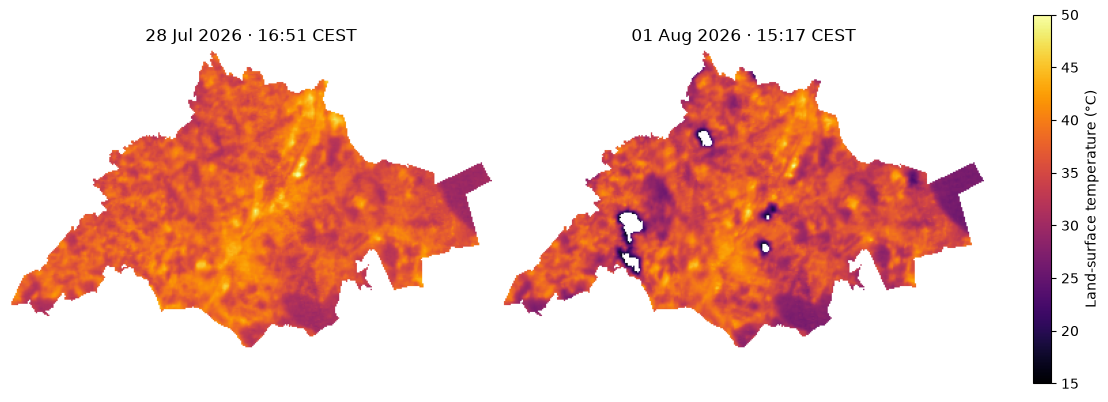

In [3]:
late = usable[usable.time.dt.hour.between(15, 18)].copy()
late['day'] = late.time.dt.date
chosen = late.sort_values(['clear_roi_%', 'time'], ascending=[False, True]).drop_duplicates('day').head(2).sort_values('time')
earthaccess.download([url(g, '_LST.tif') for g in chosen.object], cache, show_progress=False)

def load(row):
    name = row.granule
    with rasterio.open(cache / f'{name}_LST.tif') as src:
        shape = transform_geom('EPSG:4326', src.crs, roi.__geo_interface__)
        lst, transform = rio_mask(src, [shape], crop=True, filled=False)
    with rasterio.open(cache / f'{name}_cloud.tif') as src:
        cloud, _ = rio_mask(src, [shape], crop=True, filled=False)
    bad = np.ma.getmaskarray(lst[0]) | np.ma.getmaskarray(cloud[0]) | (cloud[0].data == 1)
    west, south, east, north = array_bounds(lst.shape[1], lst.shape[2], transform)
    return np.ma.array(lst[0].data - 273.15, mask=bad), (west, east, south, north)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    temperature, extent = load(row)
    image = ax.imshow(temperature, extent=extent, cmap='inferno', vmin=15, vmax=50)
    ax.set_title(row.time.strftime('%d %b %Y · %H:%M %Z'))
    ax.set_axis_off()
fig.colorbar(image, ax=axes, label='Land-surface temperature (°C)', shrink=.75)
print(chosen[['time', 'coverage_%', 'cloud_%', 'granule']].to_string(index=False))
plt.show()